In [ ]:
#SVM PROJECT

In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [11]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [12]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
df.tail(5)

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [13]:
df.shape

(400, 3)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [15]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [16]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [17]:
df.isna().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [18]:
df.Purchased.value_counts()

,count
Purchased,
0,257
1,143


<Axes: xlabel='Purchased', ylabel='count'>

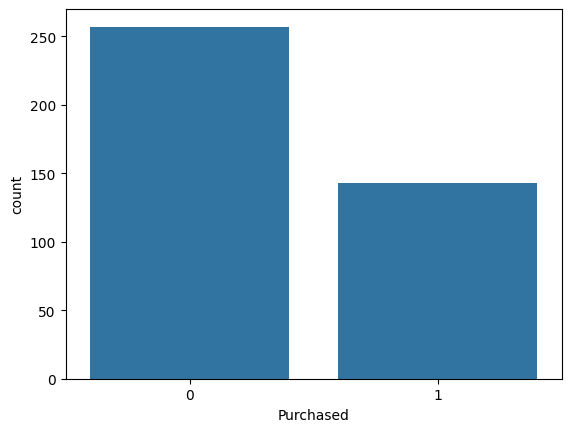

In [19]:
sn.countplot(x = 'Purchased',data=df)

In [20]:
df.Age.value_counts()

,count
Age,
35,32
37,20
26,16
42,16
41,16
39,15
40,15
48,14
47,14


<Axes: xlabel='Age', ylabel='count'>

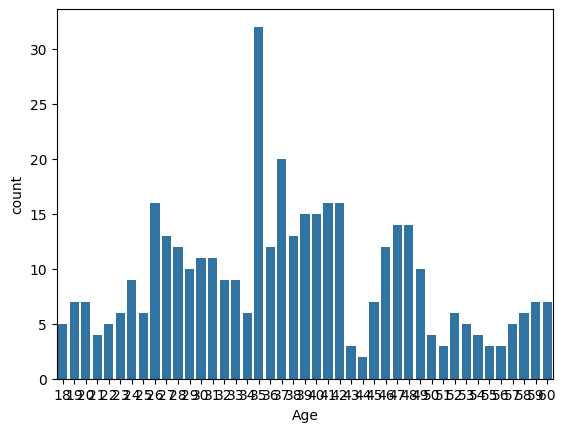

In [21]:
sn.countplot(x='Age',data=df)

<Axes: xlabel='Age'>

<Figure size 2000x1800 with 0 Axes>

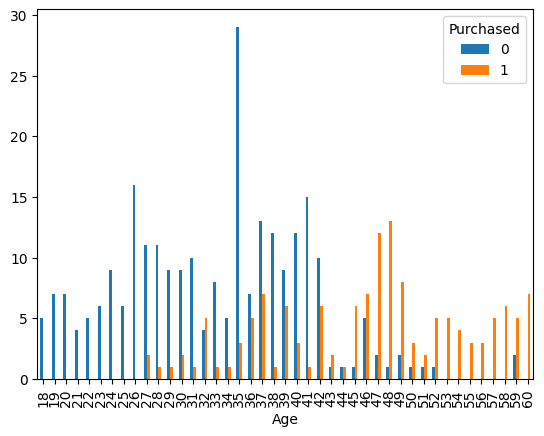

In [28]:
plt.figure(figsize=(20,18))
pd.crosstab(df.Age,df.Purchased).plot(kind="bar")

In [29]:
x = df[['Age','EstimatedSalary']]

In [30]:
y = df[['Purchased']]

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [33]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [34]:
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [35]:
from sklearn.svm import SVC
model=SVC()

In [36]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [37]:
model.score(x_test,y_test)

0.8875

In [38]:
model.predict(x_test)

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [39]:
y_predict=model.predict(x_test)

In [40]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91        49
           1       0.87      0.84      0.85        31

    accuracy                           0.89        80
   macro avg       0.88      0.88      0.88        80
weighted avg       0.89      0.89      0.89        80



In [41]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
cm

array([[45,  4],
       [ 5, 26]])

<Axes: >

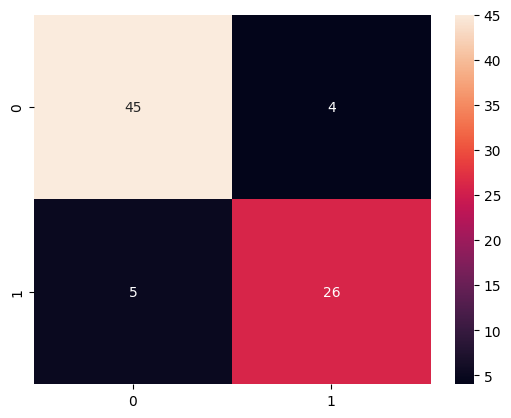

In [42]:
sn.heatmap(cm,annot=True)

In [43]:
model=SVC(C=100, kernel='linear')
model.fit(x_train,y_train)
model.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8